In [ ]:
pip install numpy pandas scikit-learn tensorflow xgboost yfinance ta shap matplotlib

  Preparing metadata (setup.py) ... done
  Created wheel for ta: filename=ta-0.11.0-py3-none-any.whl size=29412 sha256=5bfabf7c9a3ebf288c5a1fbf3003097a61f9b3c011a0c5d733e87de5caa26a9c
  Stored in directory: /root/.cache/pip/wheels/5c/a1/5f/c6b85a7d9452057be4ce68a8e45d77ba34234a6d46581777c6
Successfully built ta


In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

In [ ]:
ticker = yf.Ticker("BTC-USD")
df = ticker.history(start="2020-01-01", end="2024-01-01")

df.reset_index(inplace=True)


In [ ]:
market_cap = ticker.info.get("marketCap", None)

df["MarketCap"] = df["Close"] * df["Volume"]

In [ ]:
df.fillna(method='ffill', inplace=True)
df.dropna(inplace=True)


/tmp/ipykernel_6149/1704768335.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


In [ ]:
df['SMA_10'] = df['Close'].rolling(10).mean()
df['EMA_10'] = df['Close'].ewm(span=10).mean()

df['Volatility'] = df['Close'].rolling(10).std()

df.dropna(inplace=True)

In [ ]:
features = [
    'Open', 'High', 'Low', 'Close',
    'Volume', 'MarketCap',
    'SMA_10', 'EMA_10', 'Volatility'
]

data = df[features].values

In [ ]:
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

In [ ]:
time_steps = 120
X, y = [], []

for i in range(len(scaled_data) - time_steps):
    X.append(scaled_data[i:i+time_steps])
    y.append(scaled_data[i+time_steps][3])  # Close price

X = np.array(X)
y = np.array(y)


In [ ]:
split = int(0.8 * len(X))

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

X_train: (1065, 120, 9)
y_train: (1065,)


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

print(df.head())
print(df.info())

                        Date         Open         High          Low  \
9  2020-01-10 00:00:00+00:00  7878.307617  8166.554199  7726.774902   
10 2020-01-11 00:00:00+00:00  8162.190918  8218.359375  8029.642090   
11 2020-01-12 00:00:00+00:00  8033.261719  8200.063477  8009.059082   
12 2020-01-13 00:00:00+00:00  8189.771973  8197.788086  8079.700684   
13 2020-01-14 00:00:00+00:00  8140.933105  8879.511719  8140.933105   

          Close       Volume  Dividends  Stock Splits      MarketCap  \
9   8166.554199  28714583844        0.0           0.0  1522832113664   
10  8037.537598  25521165085        0.0           0.0  1522832113664   
11  8192.494141  22903438381        0.0           0.0  1522832113664   
12  8144.194336  22482910688        0.0           0.0  1522832113664   
13  8827.764648  44841784107        0.0           0.0  1522832113664   

         SMA_10       EMA_10  Volatility  
9   7641.090283  7835.890865  425.920748  
10  7724.826611  7877.084772  411.679785  
11  7845.52

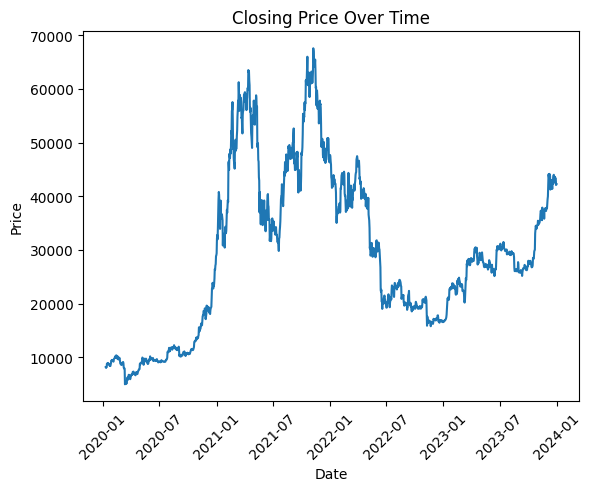

In [ ]:
plt.figure()
plt.plot(df['Date'], df['Close'])
plt.title("Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Price")
plt.xticks(rotation=45)
plt.show()

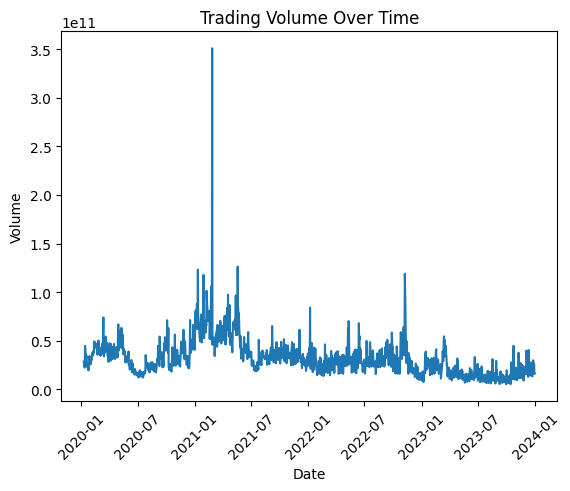

In [ ]:
plt.figure()
plt.plot(df['Date'], df['Volume'])
plt.title("Trading Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.xticks(rotation=45)
plt.show()

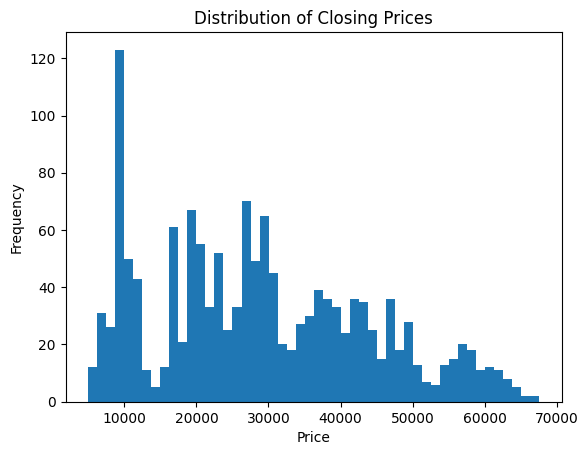

In [ ]:
plt.figure()
plt.hist(df['Close'], bins=50)
plt.title("Distribution of Closing Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

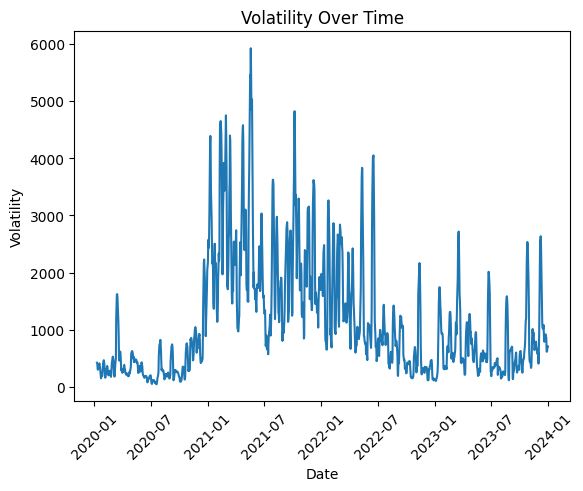

In [ ]:
plt.figure()
plt.plot(df['Date'], df['Volatility'])
plt.title("Volatility Over Time")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.xticks(rotation=45)
plt.show()

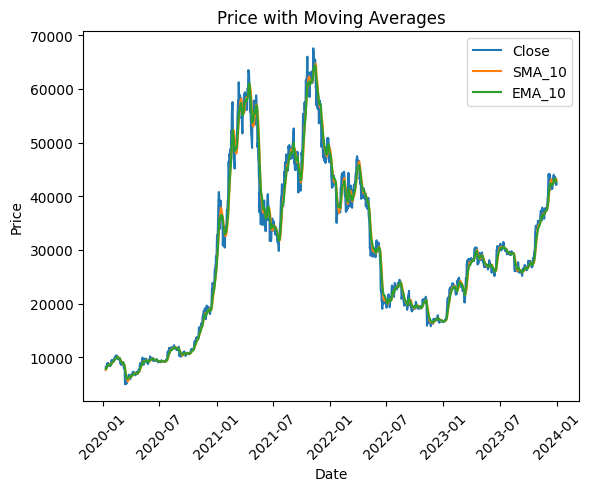

In [ ]:
plt.figure()
plt.plot(df['Date'], df['Close'], label='Close')
plt.plot(df['Date'], df['SMA_10'], label='SMA_10')
plt.plot(df['Date'], df['EMA_10'], label='EMA_10')
plt.title("Price with Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.xticks(rotation=45)
plt.show()

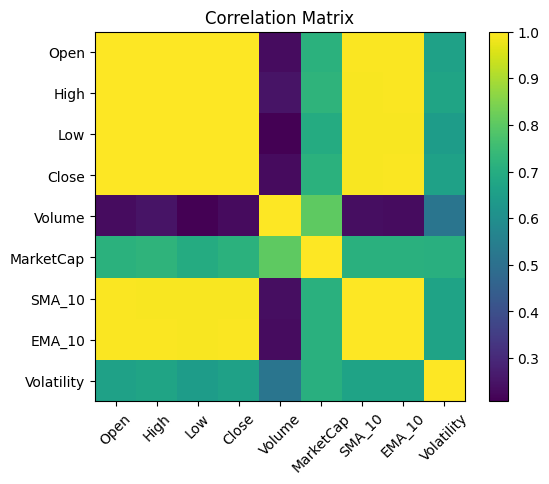

In [ ]:
plt.figure()
corr = df[['Open','High','Low','Close','Volume','MarketCap','SMA_10','EMA_10','Volatility']].corr()

plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Matrix")
plt.show()

In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

inputs = Input(shape=(120, X_train.shape[2]))


In [ ]:
x= LSTM(128, return_sequences=True)(inputs)
x = Dropout(0.2)(x)

x = LSTM(64, return_sequences=True)(x)
x = Dropout(0.2)(x)

x = LSTM(64)(x)
x = Dropout(0.1)(x)

feature_layer = Dense(64, activation='relu')(x)
output = Dense(1)(feature_layer)


In [ ]:
model = Model(inputs=inputs, outputs=output)

model.compile(optimizer='adam', loss='mse')


In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

In [ ]:
model.fit(
    X_train, y_train,
    epochs=120,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop]
)


Epoch 1/120
34/34 ━━━━━━━━━━━━━━━━━━━━ 7s 52ms/step - loss: 0.0216 - val_loss: 0.0028
Epoch 2/120
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0057 - val_loss: 9.9436e-04
Epoch 3/120
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0047 - val_loss: 0.0019
Epoch 4/120
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0043 - val_loss: 6.6060e-04
Epoch 5/120
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0033 - val_loss: 0.0016
Epoch 6/120
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0036 - val_loss: 6.1256e-04
Epoch 7/120
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0033 - val_loss: 0.0019
Epoch 8/120
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0040 - val_loss: 0.0025
Epoch 9/120
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0031 - val_loss: 5.7489e-04
Epoch 10/120
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0032 - val_loss: 5.5059e-04
Epoch 11/120
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0028 - val_loss: 7.2026e-04
Epoch 12/120
34/34 ━━━━━━━━━

In [ ]:
feature_extractor = Model(inputs=inputs, outputs=feature_layer)

In [ ]:
X_train_lstm = feature_extractor.predict(X_train)
X_test_lstm = feature_extractor.predict(X_test)

print("LSTM features shape:", X_train_lstm.shape)

34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
LSTM features shape: (1065, 64)


In [ ]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
import numpy as np


In [ ]:
from sklearn.model_selection import RandomizedSearchCV

In [ ]:
# Hyperparameter Grid
param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5, 6, 8],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'gamma': [0, 0.1, 0.2],
    'reg_alpha': [0, 0.01, 0.1],
    'reg_lambda': [1, 1.5, 2]
}

random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_grid,
    n_iter=20,
    scoring='neg_mean_squared_error',
    cv=3,
    verbose=1,
    n_jobs=-1
)

random_search.fit(X_train_lstm, y_train.ravel())

xgb_model = random_search.best_estimator_

print("Best Parameters:", random_search.best_params_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best Parameters: {'subsample': 0.7, 'reg_lambda': 1, 'reg_alpha': 0, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.05, 'gamma': 0, 'colsample_bytree': 0.7}


In [ ]:
xgb_model.fit(X_train_lstm, y_train)
y_pred = xgb_model.predict(X_test_lstm)

In [ ]:
print(xgb_model.feature_importances_)

[4.9689837e-02 1.9264102e-02 9.9573685e-03 6.6640493e-03 4.0033273e-03
 3.3020407e-02 0.0000000e+00 1.8730514e-03 4.9500443e-02 2.5194700e-04
 0.0000000e+00 2.1009126e-03 3.3052740e-05 5.5210972e-03 1.0369939e-04
 1.5561258e-04 1.1595942e-05 5.2264752e-04 3.5691713e-03 7.8163901e-04
 3.2827809e-06 0.0000000e+00 1.1613860e-03 1.9478185e-04 3.2428604e-02
 5.9961616e-03 0.0000000e+00 2.6978254e-02 9.3265418e-03 1.8612262e-04
 1.8525732e-03 1.8821163e-04 0.0000000e+00 1.3072342e-01 1.3293407e-03
 1.4573184e-04 1.2343832e-01 0.0000000e+00 3.4882509e-04 3.5535272e-06
 4.4396881e-04 2.1035537e-04 4.0426303e-04 2.9399170e-02 0.0000000e+00
 1.7753485e-01 1.7981073e-03 1.1844867e-02 9.3190279e-03 1.3671350e-05
 4.5882573e-04 0.0000000e+00 0.0000000e+00 1.5510261e-01 6.9054767e-02
 1.7717107e-04 0.0000000e+00 3.5646730e-04 1.3794855e-02 0.0000000e+00
 0.0000000e+00 7.5353333e-03 5.7904853e-04 6.4354623e-04]


In [ ]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = mean_absolute_percentage_error(y_test, y_pred)

print("RMSE:", rmse)
print("MAPE:", mape)

RMSE: 0.024602843870535348
MAPE: 0.05054619030361757


In [ ]:

y_pred_rescaled = []
y_test_rescaled = []

for i in range(len(y_pred)):
    dummy = np.zeros((1, scaled_data.shape[1]))
    dummy[0, 3] = y_pred[i]
    y_pred_rescaled.append(scaler.inverse_transform(dummy)[0, 3])

    dummy[0, 3] = y_test[i]
    y_test_rescaled.append(scaler.inverse_transform(dummy)[0, 3])

y_pred_rescaled = np.array(y_pred_rescaled)
y_test_rescaled = np.array(y_test_rescaled)

print("Actual vs Predicted:")
print(y_test_rescaled[:5])
print(y_pred_rescaled[:5])

Actual vs Predicted:
[28333.05078125 29652.98046875 30235.05859375 30139.05273438
 30399.06640625]
[28227.12819513 28168.6893114  28575.61802955 29448.61578034
 30261.04050697]


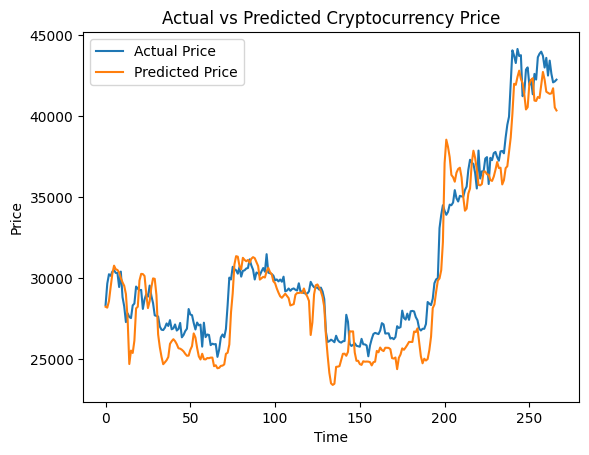

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(y_test_rescaled, label='Actual Price')
plt.plot(y_pred_rescaled, label='Predicted Price')

plt.title("Actual vs Predicted Cryptocurrency Price")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()

plt.show()

In [ ]:
#prediction for the next 7 days

In [ ]:
import numpy as np

future_days = 7

last_sequence = scaled_data[-time_steps:].copy()

future_preds = []

for _ in range(future_days):

    input_seq = last_sequence.reshape(
        1,
        time_steps,
        scaled_data.shape[1]
    )

    lstm_features = feature_extractor.predict(
        input_seq,
        verbose=0
    )

    pred = xgb_model.predict(lstm_features)[0]

    pred = 0.8 * pred + 0.2 * last_sequence[-1, 3]

    future_preds.append(pred)

    new_row = last_sequence[-1].copy()

    new_row[0] = pred  
    new_row[1] = pred  
    new_row[2] = pred  
    new_row[3] = pred  

    last_sequence = np.concatenate(
        [last_sequence[1:], new_row.reshape(1, -1)],
        axis=0
    )

future_prices = []

for pred in future_preds:
    dummy = np.zeros((1, scaled_data.shape[1]))
    dummy[0, 3] = pred

    actual_price = scaler.inverse_transform(dummy)[0, 3]
    future_prices.append(actual_price)

future_prices = np.array(future_prices)

print("\nNext 7 Days Prediction:")
print("-" * 30)

for i, price in enumerate(future_prices, start=1):
    print(f"Day {i}: ₹{price:.2f}")

: 